In [29]:
import pandas as pd, numpy as np, matplotlib, matplotlib.pyplot as plt, datetime

# quick method for area-weighted averaging (will add to WWA main but need to generalise dims first)
def awmean(da): return da.weighted(np.cos(np.deg2rad(da.lat))).mean(["lat", "lon"])

## Compute from monthly

In [ ]:
# ! wget https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv -O data/gmst-monthly_gistemp.csv

In [53]:
# reshape to long dataframe
df = pd.read_csv("data/gmst-monthly_gistemp.csv", skiprows = 1, na_values = ["****", "***"]).iloc[:,:13]
df = df.rename(columns = dict(zip(df.columns[1:], range(1,13))))
df = pd.melt(df, id_vars = "Year", value_vars = df.columns).dropna(axis = 0, how = "any")

df["date"] = [datetime.datetime(r.Year, r.variable, 1) for k, r in df.iterrows()]
df = df.set_index("date").rename(columns = {"value" : "gmst"})[["gmst"]].sort_index()

## Compare to climate explorer

In [ ]:
# ! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O data/gmst-smoothed_climexp.dat
# ! wget https://climexp.knmi.nl/data/igiss_al_gl_a.dat -O data/gmst-annual_climexp.dat

In [78]:
cx_ann = pd.read_csv("data/gmst-annual_climexp.dat", comment = "#", header = None, sep = " +", engine = "python", names = ["year", "gmst"], index_col = "year")
cx_ann.index = [datetime.datetime(y, 7, 1) for y in cx_ann.index]

cx_sm = pd.read_csv("data/gmst-smoothed_climexp.dat", comment = "#", header = None, sep = " +", engine = "python", names = ["year", "gmst"], index_col = "year")
cx_sm.index = [datetime.datetime(y, 7, 1) for y in cx_sm.index]
cx_sm = cx_sm.loc[slice(None, "2028")]

In [ ]:
df.plot(color = "tab:orange", alpha = 0.5, label = "GISTEMP monthly")
cx_ann.plot(ax = plt.gca(), color = "tab:red",  label = "CX annual")
cx_sm.plot(ax = plt.gca(), color = "k", label = "CX smoothed")

plt.legend(["GISTEMP monthly", "CX annual", "CX smoothed"])

In [ ]:
# alternative method using rolling mean - centre on 25th month, which is first of third year
rmean_centred = df.rolling(49, center = True, min_periods = 25).mean()

In [ ]:
# how would previous years have compared?
rmean_truncated = df.rolling(25, center = False).mean()
cx_truncated = cx_ann.rolling(3, center = False).mean()

In [202]:
# pad with persistence value
df_padded = pd.concat([df, pd.DataFrame(np.repeat(np.nan,12),
                                        index = pd.date_range(start = df.index.max(), periods = 13, freq = "MS")[1:], 
                                        columns = ["gmst"])]).loc[slice(None, str(df.index.max().year))].ffill()

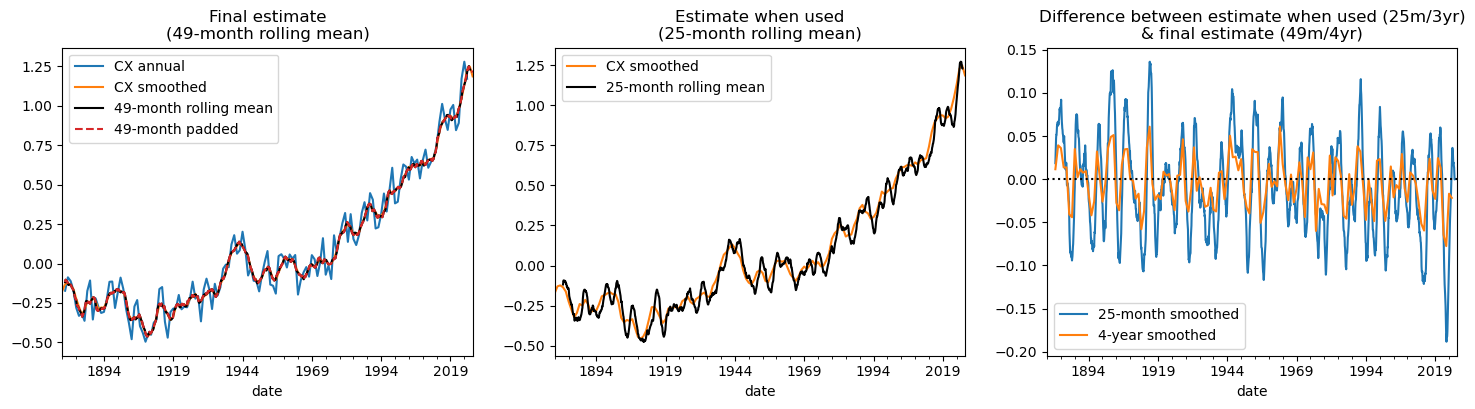

In [203]:
fig, axs = plt.subplots(ncols = 3, figsize = (18,4), dpi = 100)

ax = axs[0]
cx_ann.plot(ax = ax)
cx_sm.plot(ax = ax)
rmean_centred.plot(ax = ax, color = "k")
df_padded.rolling(49, center = True, min_periods = 25).mean().plot(ax = ax, color = "tab:red", ls = "--")
ax.legend(["CX annual", "CX smoothed", "49-month rolling mean", "49-month padded"])
ax.set_title("Final estimate\n(49-month rolling mean)")

ax = axs[1]
# cx_ann.plot(ax = ax)
cx_sm.plot(ax = ax, color = "tab:orange")
rmean_truncated.plot(ax = ax, color = "k")
ax.legend(["CX smoothed", "25-month rolling mean"])
ax.set_title("Estimate when used\n(25-month rolling mean)")

ax = axs[2]
(rmean_truncated - rmean_centred).plot(ax = axs[2])
(cx_truncated - cx_sm).plot(ax = axs[2])
ax.set_title("Difference between estimate when used (25m/3yr)\n& final estimate (49m/4yr)")
ax.axhline(0, color = "k", ls = ":")
ax.legend(["25-month smoothed", "4-year smoothed"])